In [1]:
from wjp_judicial_independence.config import PATH_DATA_INTERIM                                                                        
from wjp_judicial_independence.plot import *
from wjp_judicial_independence.analysis import compare_strategies                                                                   
import polars as pl
from bertopic import BERTopic

# Para ignorar advertencias
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# Visualización
Los objetivos de este módulo son:
1. Visualizar la distribución de temas identificados en el Módulo II por país. Es
importante, a la vez, comparar el "sentimiento" de la independencia judicial
entre Italia, Hungría y Polonia basándose en los datos.
2. Ver una lista de eventos críticos detectados por tu sistema.
3. Incluir un análisis crítico de los resultados
4. Añadir un análisis de la calidad de los datos y de las limitaciones del sistema.

Resolver la Pregunta final (bonus):
Si este sistema tuviera que escalar para procesar 50 países y 100 veces más noticias, ¿qué
cambios introducirías en la arquitectura para garantizar eficiencia y robustez? ¿Qué
estrategias implementarías específicamente para optimizar costos computacionales y de
uso de modelos (por ejemplo, LLMs o embeddings)?

In [35]:
# Cambiar la estrategia de clasificación de noticias de independencia judicial

MODULE1_STRATEGY = "llm" # opciones: "llm" | "llm-api" | "embeddings"

In [36]:
df = pl.read_parquet(PATH_DATA_INTERIM/f"module2/sentiment/df_m1_{MODULE1_STRATEGY}_strategy_judicial_independence.parquet")

# 1. Distribución de Temas
### 1.1 Distribución de Temas generales de Independencia Judicial

In [37]:
topic_model = BERTopic.load(PATH_DATA_INTERIM/f"module2/topic_modelling/bertopic_general_m1_{MODULE1_STRATEGY}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

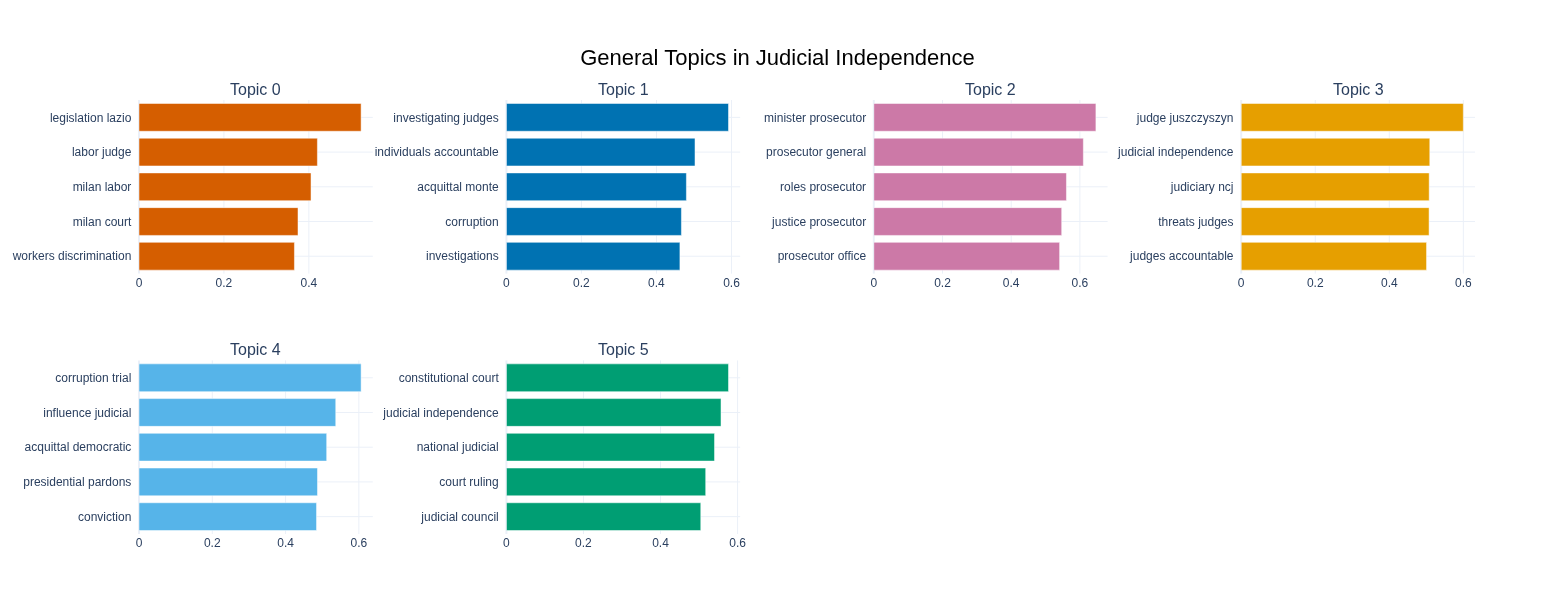

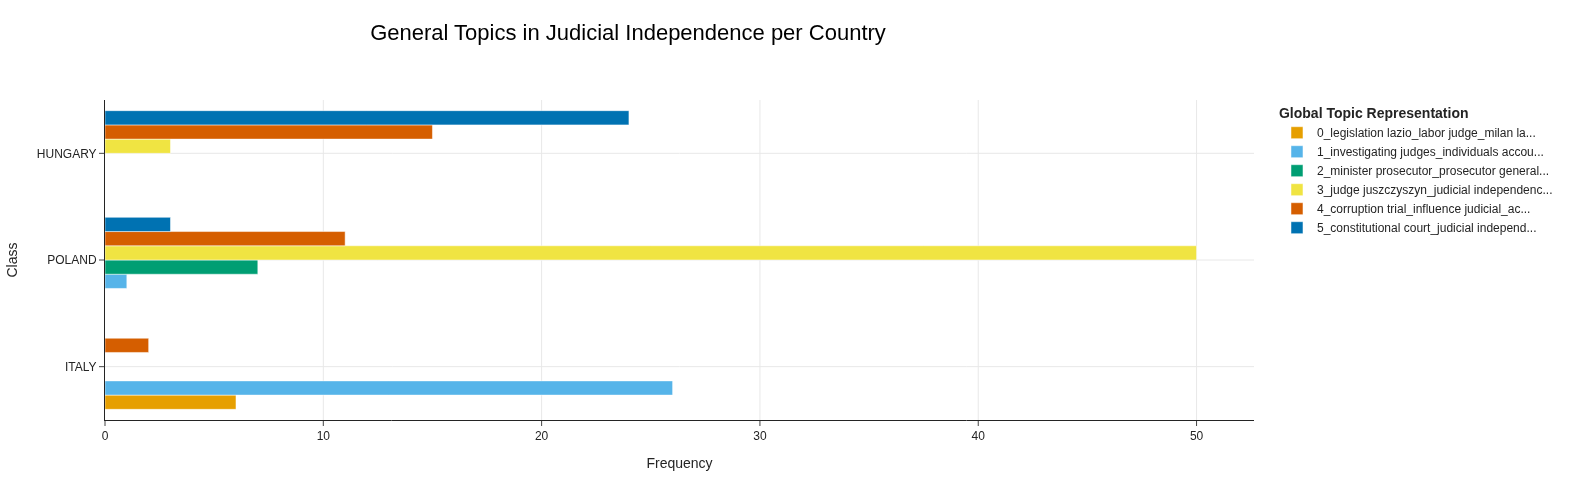

In [38]:
fig = topic_model.visualize_barchart(width=400, height=300, title="General Topics in Judicial Independence")
fig.show()

topics_per_class = topic_model.topics_per_class(df["event"], classes=df["country"])
fig = topic_model.visualize_topics_per_class(topics_per_class, title="General Topics in Judicial Independence per Country", width=1200, height=500, normalize_frequency=False)
fig.update_traces(visible=True)
fig.show()

### 1.2 Comparación del Sentimiento de Independencia Judicial por País

In [39]:
topics_per_class_per_country = []
for country in df["country"].unique().to_list():
    topic_model = BERTopic.load(PATH_DATA_INTERIM / f"module2/topic_modelling/bertopic_{country}_m1_{MODULE1_STRATEGY}")
    df_country = df.filter(pl.col("country") == country)
    topics_per_class = topic_model.topics_per_class(df_country["event"], classes=df_country["judicial_independence_sentiment"])
    topics_per_class_per_country.append((topics_per_class, country))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

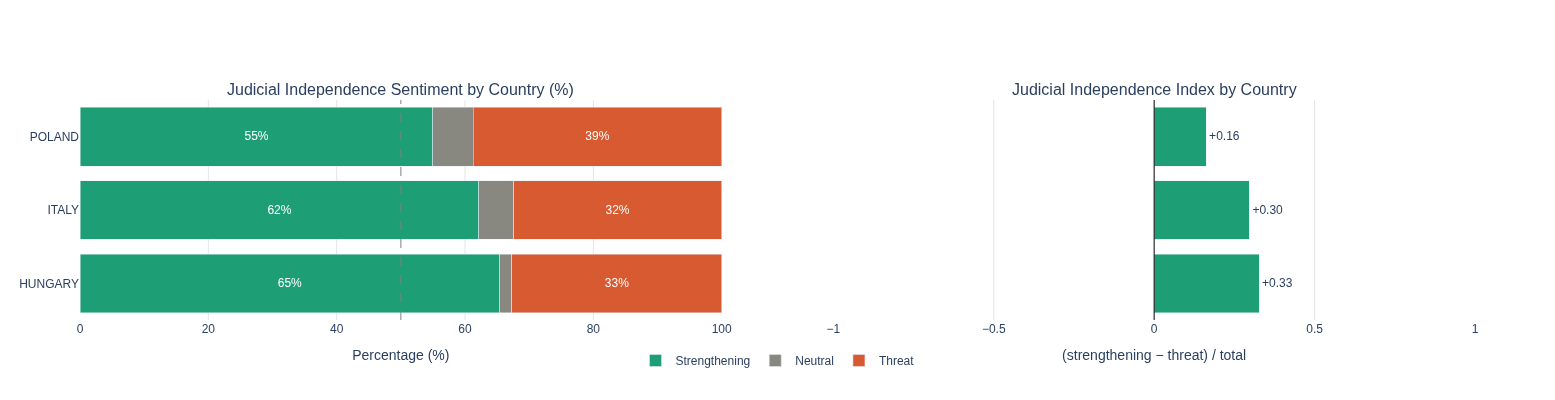

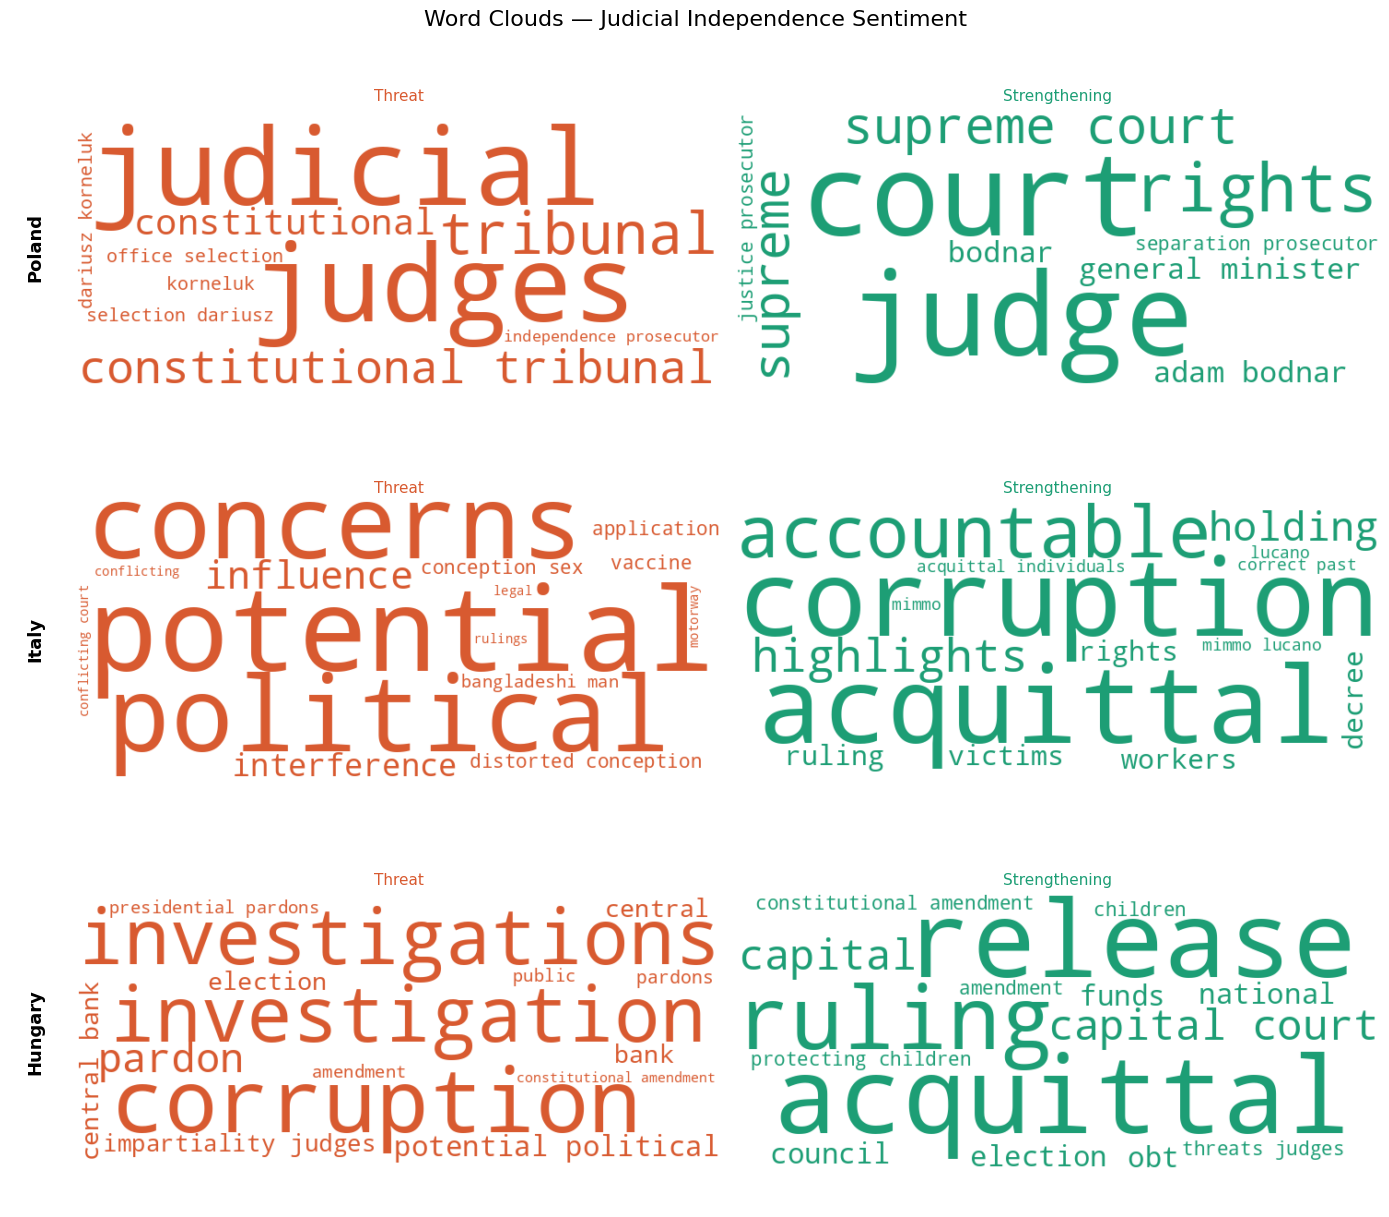

In [40]:
fig = plot_ji_sentiment(df)
plot_sentiment_wordclouds(topics_per_class_per_country)

### 1.3 Temas de Independencia Judicial Detallado por País

Cambiar la variable `COUNTRY` para ver como cambian los temas de Independencia Judicial que se hablan dentro cada país

In [41]:
COUNTRY = "POLAND" # "POLAND" | "ITALY" | "HUNGARY" 

In [42]:
topic_model = BERTopic.load(PATH_DATA_INTERIM/f"module2/topic_modelling/bertopic_{COUNTRY}_m1_{MODULE1_STRATEGY}")
df_country = df.filter(pl.col("country") == COUNTRY)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

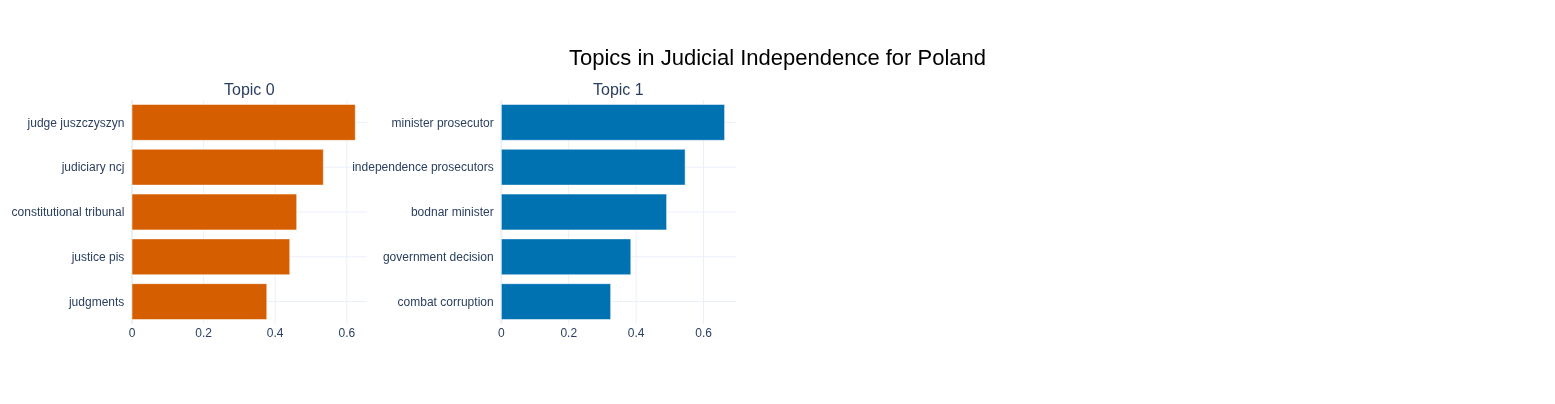

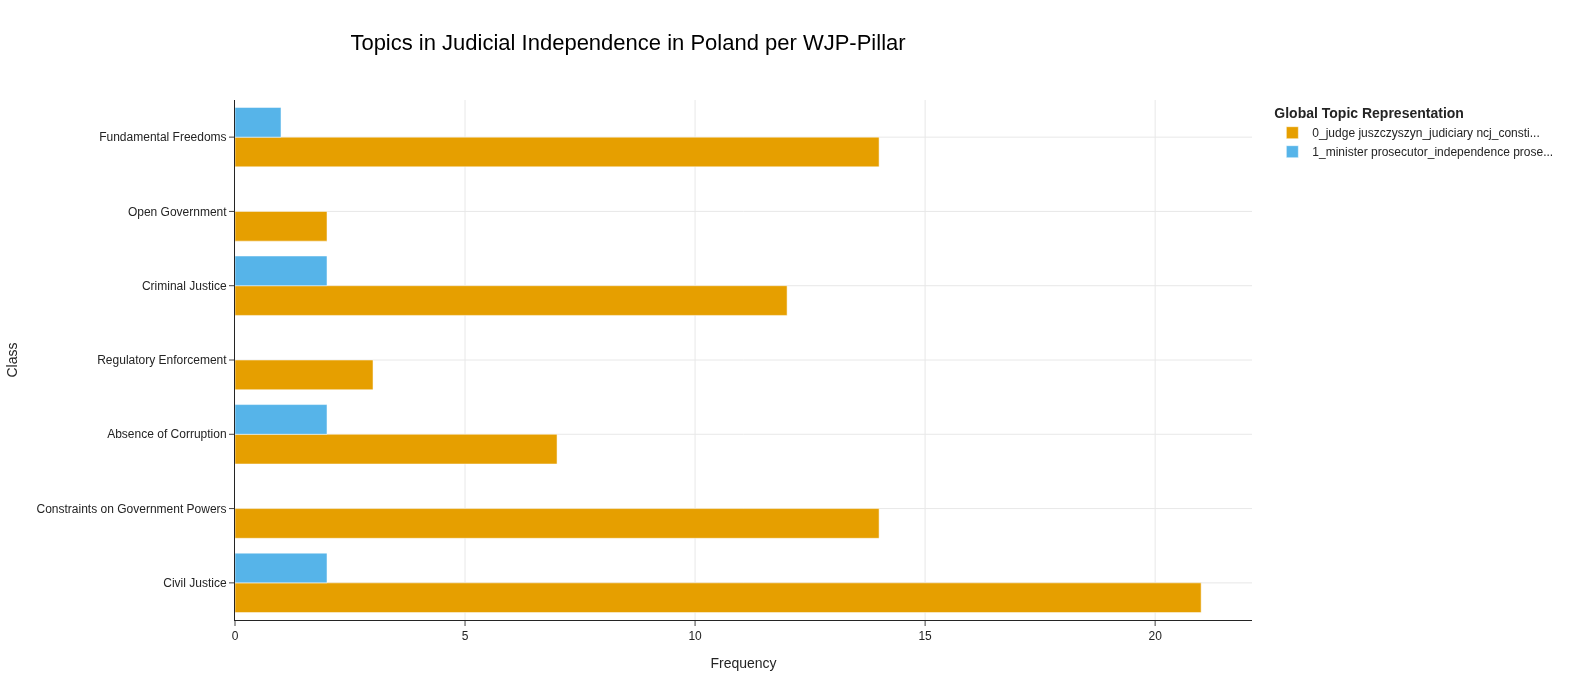

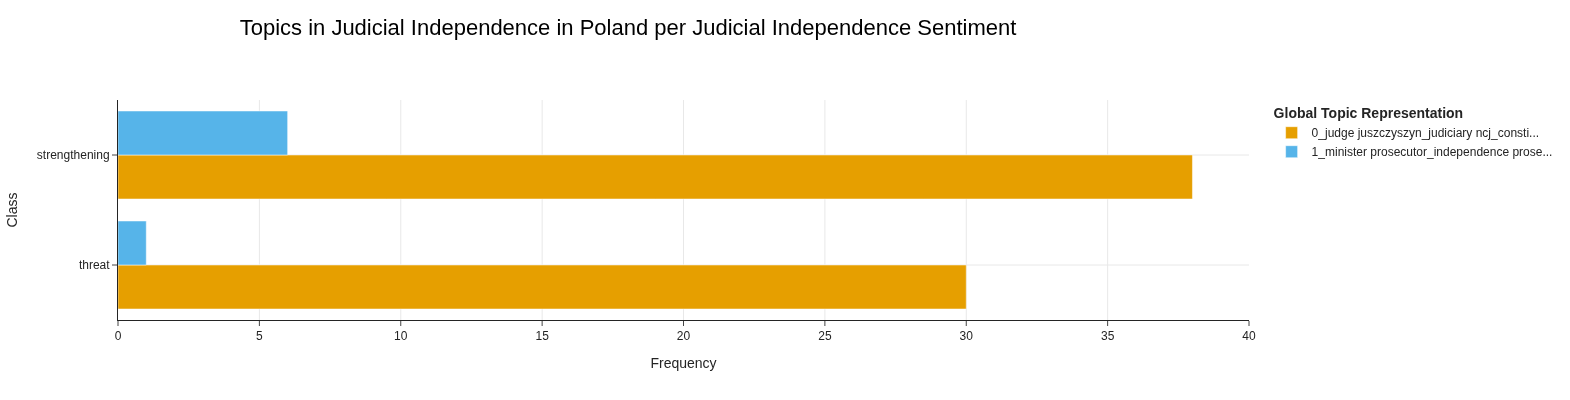

In [44]:
fig = topic_model.visualize_barchart(width=400, height=300, title=f"Topics in Judicial Independence for {COUNTRY.capitalize()}")
fig.show()

topics_per_class = topic_model.topics_per_class(df_country["event"], classes=df_country["pillar"])
fig = topic_model.visualize_topics_per_class(topics_per_class, title=f"Topics in Judicial Independence in {COUNTRY.capitalize()} per WJP-Pillar", width=1200, height=700, normalize_frequency=False)
fig.update_traces(visible=True)
fig.show()

topics_per_class = topic_model.topics_per_class(df_country["event"], classes=df_country["judicial_independence_sentiment"])
topics_per_class = topics_per_class[topics_per_class["Class"] != "neutral"]
fig = topic_model.visualize_topics_per_class(topics_per_class, title=f"Topics in Judicial Independence in {COUNTRY.capitalize()} per Judicial Independence Sentiment", width=1200, height=400, normalize_frequency=False)
fig.update_traces(visible=True)
fig.show()

# 2. Eventos Críticos/Interesantes

### 2.1 Eventos Críticos

Eventos que tienen un puntaje alto en alguno de los indicadores de independencia judicial (basándose en la estrategia 1 del módulo 1)

In [45]:
TOP_EVENTS_PER_COUNTRY = 5

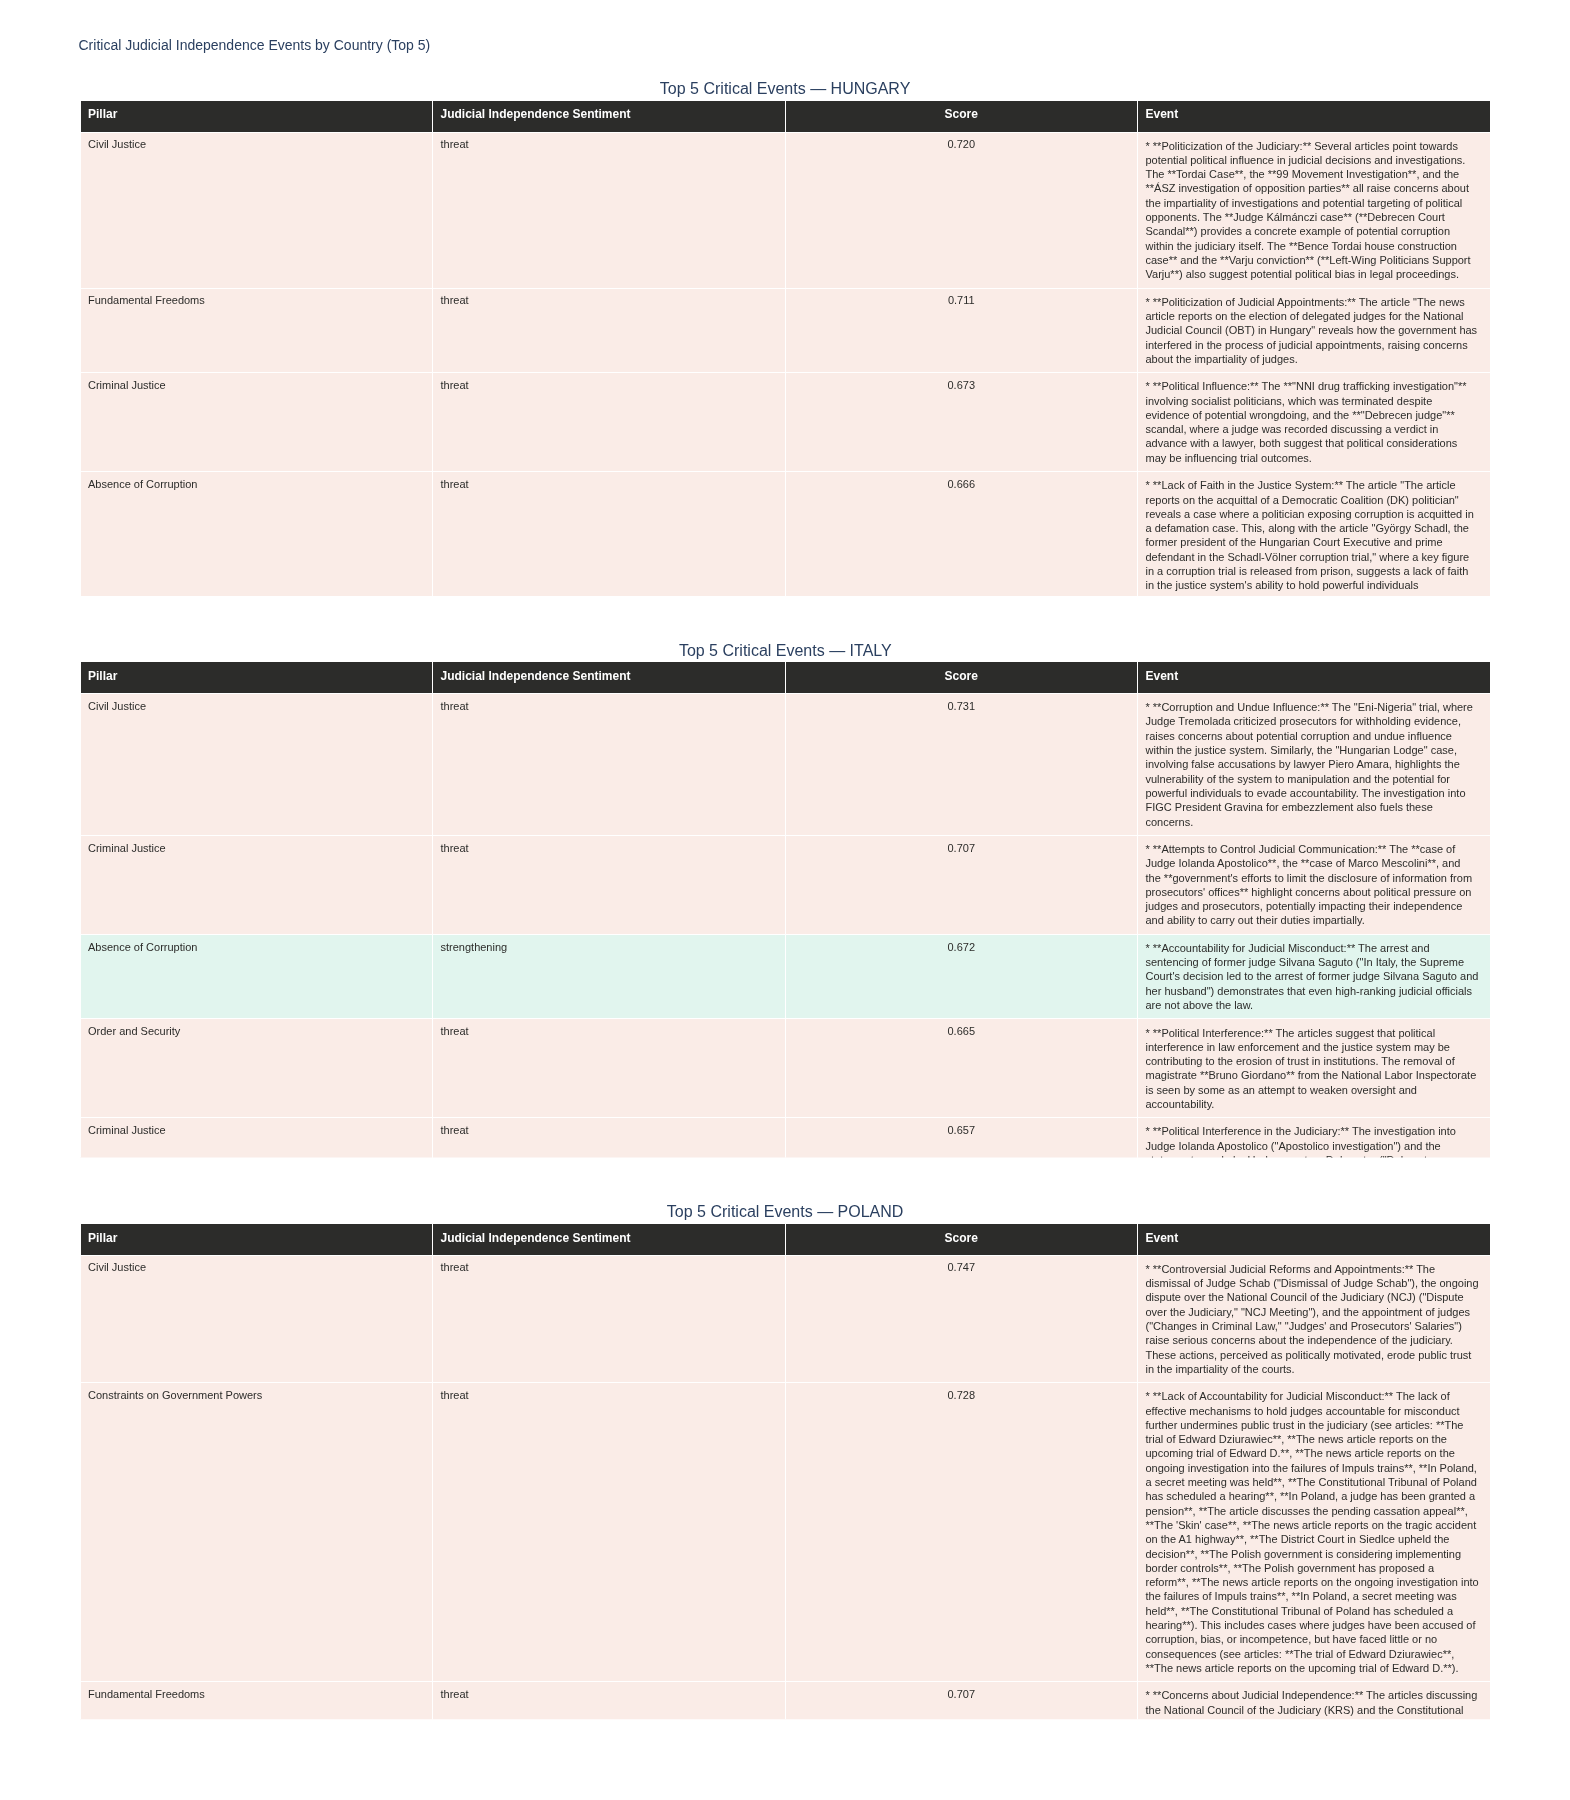

In [46]:
fig = plot_critical_events(df, top_n = TOP_EVENTS_PER_COUNTRY)

### 2.2 Eventos Interesantes

Eventos que tienen un impacto contrario/distinto al sentimiento de independencia judicial. Es decir:
- Noticias que tienen un impacto positivo en el pilar pero un sentimiento de independencia judicial negativo (amenaza)
- Noticias que tienen un impacto negativo en el pilar pero un sentimiento de independencia judicial positivo (fortalecimiento)
- Noticias que tienen un impacto neutral en el pilar pero un sentimiento de independencia judicial positivo/negativo (amenaza/fortalecimiento) 

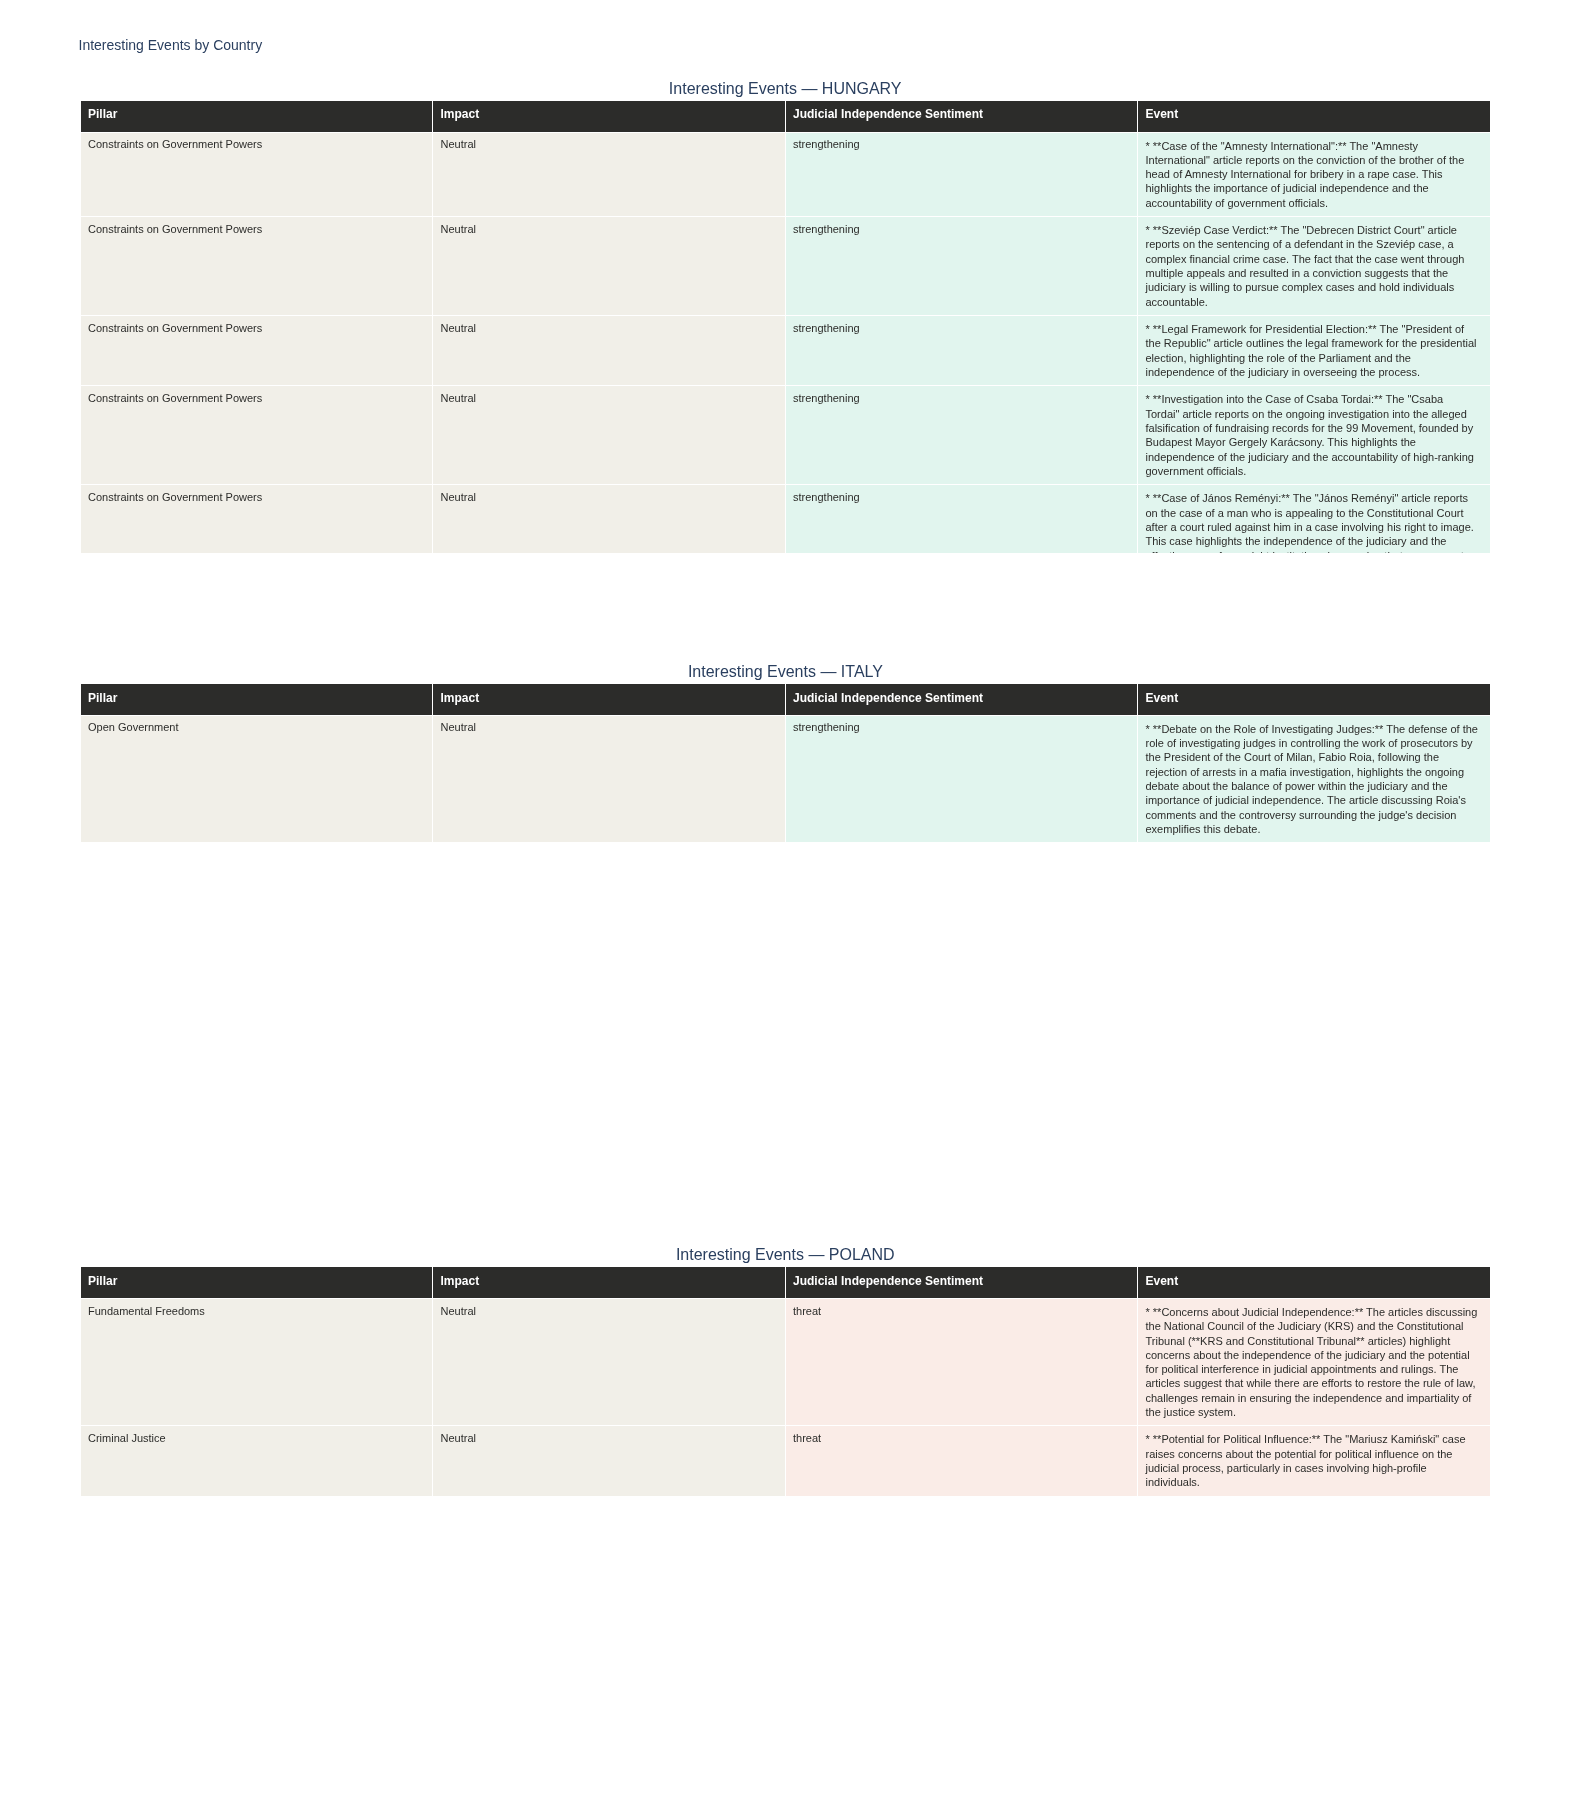

In [47]:
fig = plot_interesting_events(df)

# 3. Análisis de Resultados

## 3.1 Comparación de Estrategias de Clasificación de Noticias de Independencia Judicial

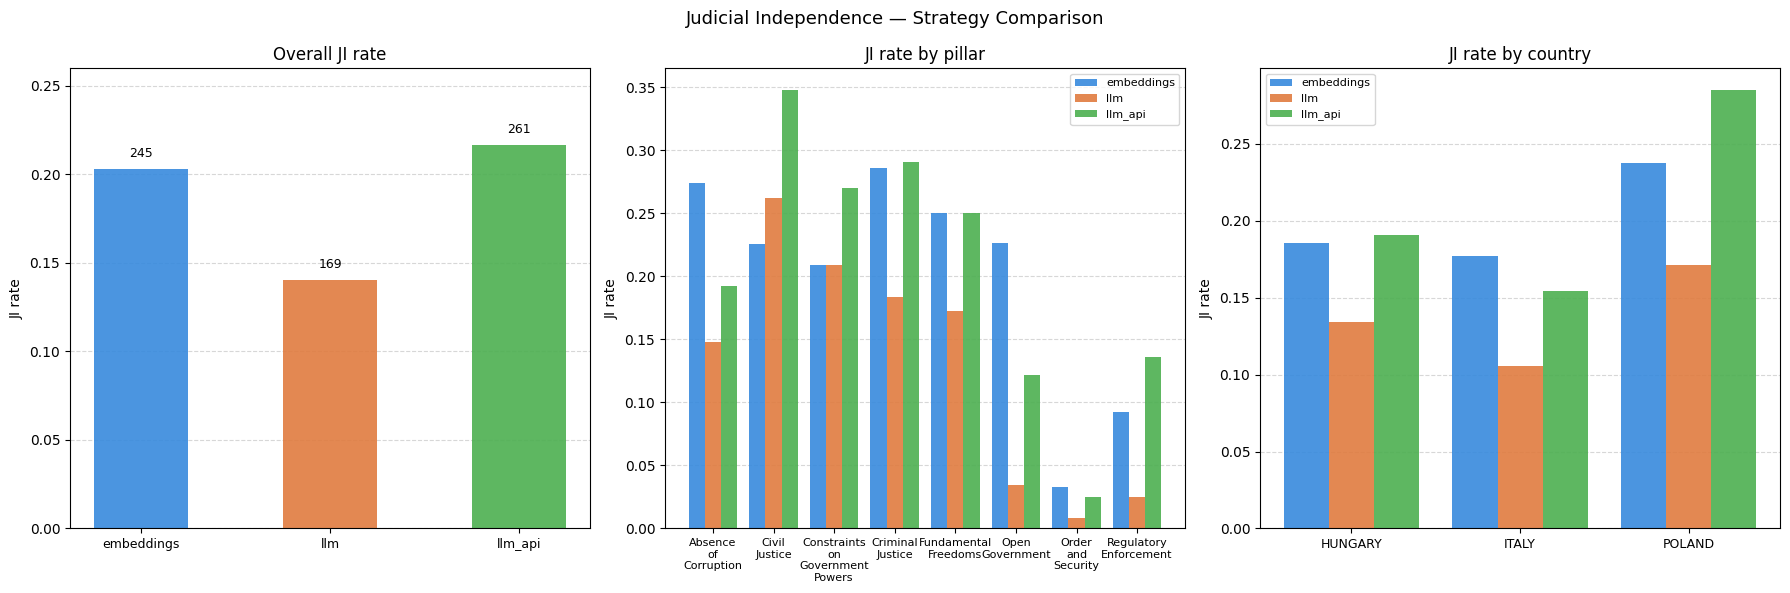

Similitud entre estrategias de clasificación:


,strategy_a,strategy_b,agreement_rate
0,embeddings,llm,0.825726
1,embeddings,llm_api,0.825726
2,llm,llm_api,0.892116


In [19]:
dfs = {
  "embeddings": pl.read_parquet(PATH_DATA_INTERIM / "module1/df_embeddings_strategy_judicial_independence.parquet"),
  "llm":        pl.read_parquet(PATH_DATA_INTERIM / "module1/df_llm_strategy_judicial_independence.parquet"),                           
  "llm_api":    pl.read_parquet(PATH_DATA_INTERIM / "module1/df_llm-api_strategy_judicial_independence.parquet")
} 

results = compare_strategies(dfs)

print("Similitud entre estrategias de clasificación:")
display(results["agreement"].to_pandas())

# 4.